In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/cleaned_netflix.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,NaN,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,NaN,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,NaN,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,NaN,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,NaN,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8790, 10)


In [4]:
df["country"].head(20)

,country
0,United States
1,France
2,United States
3,Brazil
4,United States
5,United Kingdom
6,United States
7,India
8,Germany
9,India


In [5]:
country_df = df.copy()
country_df["country"] = country_df["country"].str.split(", ")
country_df = country_df.explode("country")
country_df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,NaN,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,NaN,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,NaN,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,NaN,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,NaN,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
country_df["country"] = country_df["country"].str.strip()

In [7]:
print("Missing country values:", country_df["country"].isnull().sum())

Missing country values: 0


In [8]:
country_counts = country_df["country"].value_counts()

print(country_counts.head(20))

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Egypt              123
Australia          114
Turkey             112
Nigeria            105
Germany            104
China              100
Brazil              88
Taiwan              86
Indonesia           86
Name: count, dtype: int64


In [9]:
top_10_countries = country_counts.head(10)

print(top_10_countries)

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64


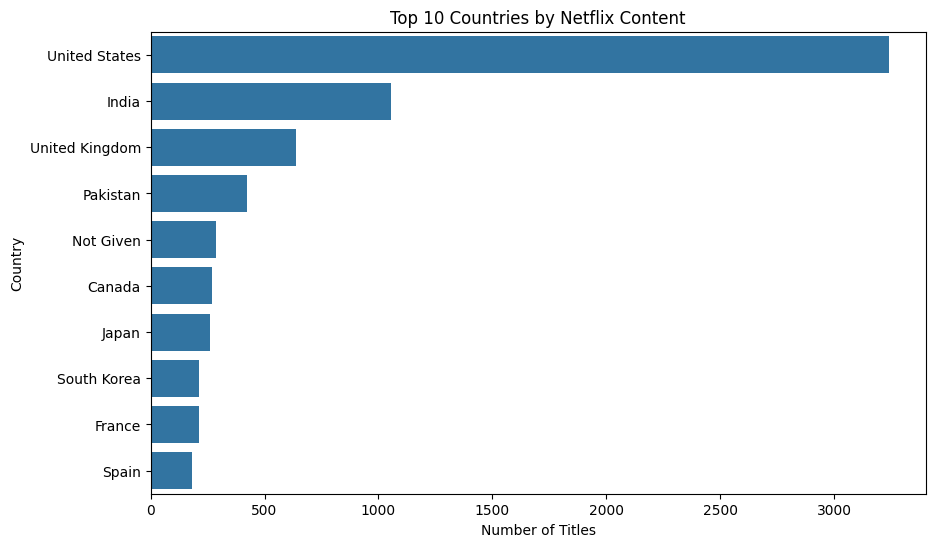

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [12]:
country_ranking = top_10_countries.reset_index()

country_ranking.columns = ["Country", "Number of Titles"]

country_ranking

,Country,Number of Titles
0,United States,3240
1,India,1057
2,United Kingdom,638
3,Pakistan,421
4,Not Given,287
5,Canada,271
6,Japan,259
7,South Korea,214
8,France,213
9,Spain,182


Conclusion:

The country-wise analysis shows that the United States has the highest
number of Netflix titles in the dataset, with 3,240 titles. India ranks
second with 1,057 titles, followed by the United Kingdom with 638 titles.
The results indicate that Netflix content in this dataset is strongly
represented by the United States, India, and the United Kingdom.

The analysis also contains 287 records where country information is
listed as "Not Given". These records were retained because the original
dataset does not provide a specific country for them.